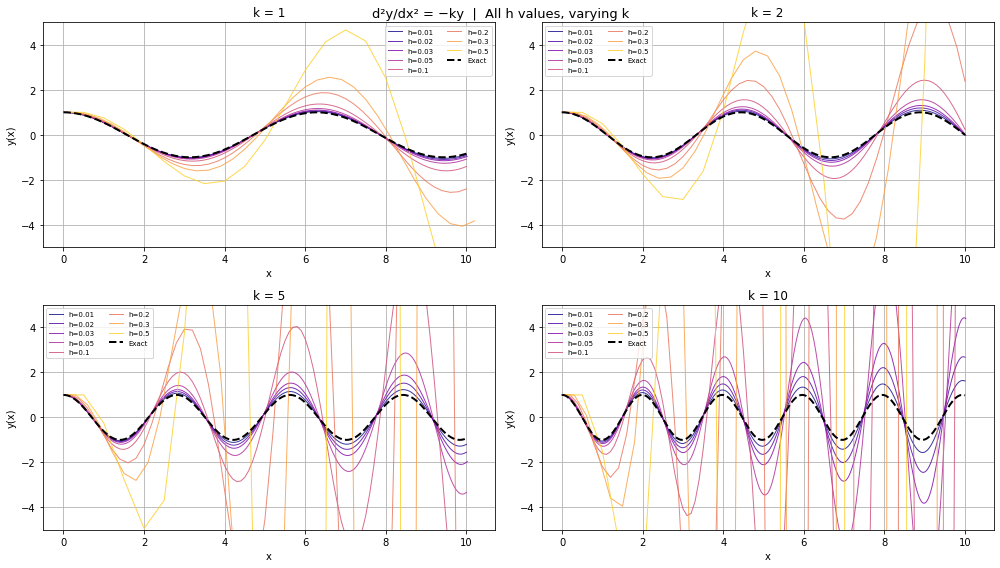

In [8]:
import numpy as np
import matplotlib.pyplot as plt

x_start = 0
x_end = 10
y_0 = 1.0
v_0 = 0.0

h_values = [0.01, 0.02, 0.03, 0.05, 0.1, 0.2, 0.3, 0.5]
k_values = [1, 2, 5, 10]

colors = plt.cm.plasma(np.linspace(0, 0.9, len(h_values)))

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for ax, k in zip(axes, k_values):

    for j, h in enumerate(h_values):
        x_values = np.arange(x_start, x_end + h, h)
        y_values = np.zeros(len(x_values))
        v_values = np.zeros(len(x_values))

        y_values[0] = y_0
        v_values[0] = v_0

        for i in range(1, len(x_values)):
            y_n = y_values[i - 1]
            v_n = v_values[i - 1]
            y_values[i] = y_n + h * v_n
            v_values[i] = v_n + h * (-k * y_n)

        ax.plot(x_values, y_values, color=colors[j], lw=1.0, alpha=0.8, label=f'h={h}')

    # Exact solution
    x_exact = np.linspace(x_start, x_end, 1000)
    ax.plot(x_exact, np.cos(np.sqrt(k) * x_exact), 'k--', lw=2, label='Exact')

    ax.set_title(f'k = {k}')
    ax.set_ylim(-5, 5)
    ax.set_xlabel('x')
    ax.set_ylabel('y(x)')
    ax.legend(fontsize=7, ncol=2)
    ax.grid(True)

fig.suptitle("d²y/dx² = −ky  |  All h values, varying k", fontsize=13)
plt.tight_layout()
plt.savefig('euler_demo_all.png', dpi=150)
plt.show()